## Settings

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8")

## Data

In [10]:
#Datos desde 2018 de diferentes activos financieros
tickers = ["AAPL", "MSFT", "JNJ", "XOM", "SPY"]

raw_data = yf.download(tickers, start="2018-01-01", auto_adjust=False)

if isinstance(raw_data.columns, pd.MultiIndex):
    data = raw_data.xs('Adj Close', axis=1, level=0)
else:
    data = raw_data['Adj Close']
    
data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,JNJ,MSFT,SPY,XOM
Date,,,,,
2018-01-02,40.304161,110.764191,78.870377,237.208206,58.580421
2018-01-03,40.297153,111.822273,79.237396,238.708633,59.730942
2018-01-04,40.484329,111.814316,79.934799,239.714722,59.813614
2018-01-05,40.945263,112.737122,80.925865,241.312210,59.765381
2018-01-08,40.793182,112.880333,81.008423,241.753448,60.034077


## 3. Compute Returns & Covariance

In [5]:
returns = np.log(data / data.shift(1)).dropna()
returns.head()

Ticker,AAPL,JNJ,MSFT,SPY,XOM
Date,,,,,
2018-01-03,-0.000174,0.009507,0.004643,0.006305,0.019449
2018-01-04,0.004634,-0.000071,0.008763,0.004206,0.001384
2018-01-05,0.011321,0.008220,0.012322,0.006642,-0.000807
2018-01-08,-0.003721,0.001269,0.001020,0.001827,0.004486
2018-01-09,-0.000114,0.015733,-0.000680,0.002261,-0.004255


In [6]:
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

In [8]:
mean_returns


Ticker
AAPL    0.230476
JNJ     0.099300
MSFT    0.199330
SPY     0.130236
XOM     0.119095
dtype: float64

In [9]:
cov_matrix

Ticker,AAPL,JNJ,MSFT,SPY,XOM
Ticker,,,,,
AAPL,0.094241,0.018857,0.059995,0.045899,0.028625
JNJ,0.018857,0.038283,0.017112,0.017054,0.017246
MSFT,0.059995,0.017112,0.081730,0.044267,0.022101
SPY,0.045899,0.017054,0.044267,0.037559,0.030524
XOM,0.028625,0.017246,0.022101,0.030524,0.091104


## 4. Portfolio Performance

In [11]:
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    
    # Retorno esperado
    portfolio_return = np.dot(weights, mean_returns)
    
    # Volatilidad
    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix, weights))
    )
    
    # Sharpe Ratio
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    
    return portfolio_return, portfolio_volatility, sharpe_ratio

Test Equal Weights

In [12]:
num_assets = len(mean_returns)

equal_weights = np.array(num_assets * [1. / num_assets])

portfolio_performance(equal_weights, mean_returns, cov_matrix)

(np.float64(0.15568731251091747),
 np.float64(0.19455335560024253),
 np.float64(0.6974298237739999))

## 5. Minimum Neg Sharpe Ratio

In [13]:
def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[2]

In [14]:
num_assets = len(mean_returns)

constraints = (
    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
)

bounds = tuple((0, 1) for _ in range(num_assets))

initial_weights = num_assets * [1. / num_assets]

Optimization

In [15]:
optimal = minimize(
    negative_sharpe,
    initial_weights,
    args=(mean_returns, cov_matrix),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

In [16]:
optimal_weights = optimal.x
optimal_weights

array([4.07215236e-01, 2.47882110e-01, 2.67442629e-01, 1.39807870e-16,
       7.74600241e-02])

In [17]:
opt_return, opt_volatility, opt_sharpe = portfolio_performance(
    optimal_weights,
    mean_returns,
    cov_matrix
)

opt_return, opt_volatility, opt_sharpe

(np.float64(0.18100227020570006),
 np.float64(0.21656236880175256),
 np.float64(0.7434452767418988))

Weights

In [19]:
weights_df = pd.DataFrame({
    "Asset": mean_returns.index,
    "Optimal Weight": optimal_weights
})

# Convertir a porcentaje
weights_df["Optimal Weight"] = weights_df["Optimal Weight"] * 100

# Ordenar de mayor a menor
weights_df = weights_df.sort_values(by="Optimal Weight", ascending=False)

# Redondear
weights_df["Optimal Weight"] = weights_df["Optimal Weight"].round(2)

weights_df

,Asset,Optimal Weight
0,AAPL,40.72
2,MSFT,26.74
1,JNJ,24.79
4,XOM,7.75
3,SPY,0.00


Results

In [21]:
print("Portafolio Óptimo (Máximo Sharpe)\n")

print(f"Retorno Esperado Anual: {opt_return:.2%}")
print(f"Volatilidad Anual: {opt_volatility:.2%}")
print(f"Sharpe Ratio: {opt_sharpe:.2f}")

Portafolio Óptimo (Máximo Sharpe)

Retorno Esperado Anual: 18.10%
Volatilidad Anual: 21.66%
Sharpe Ratio: 0.74


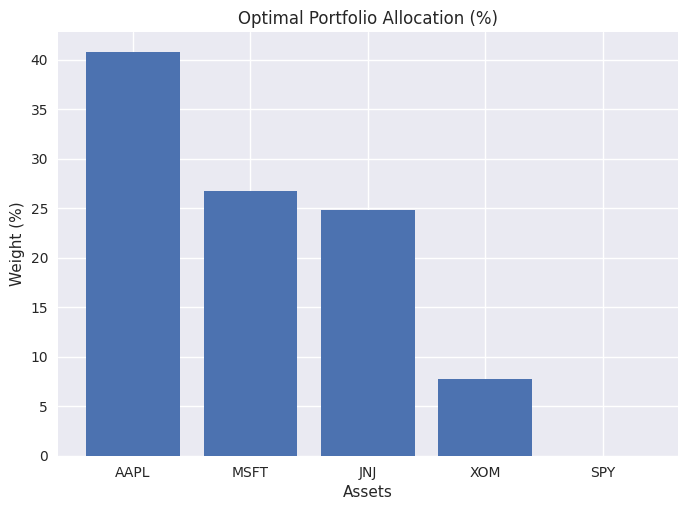

In [22]:
plt.figure()
plt.bar(weights_df["Asset"], weights_df["Optimal Weight"])
plt.title("Optimal Portfolio Allocation (%)")
plt.xlabel("Assets")
plt.ylabel("Weight (%)")
plt.show()

## Efficient Frontier

In [23]:
num_portfolios = 5000
results = np.zeros((3, num_portfolios))

all_weights = []

for i in range(num_portfolios):
    
    # Generar pesos aleatorios
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    
    all_weights.append(weights)
    
    portfolio_return, portfolio_volatility, sharpe_ratio = portfolio_performance(
        weights, mean_returns, cov_matrix
    )
    
    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = sharpe_ratio

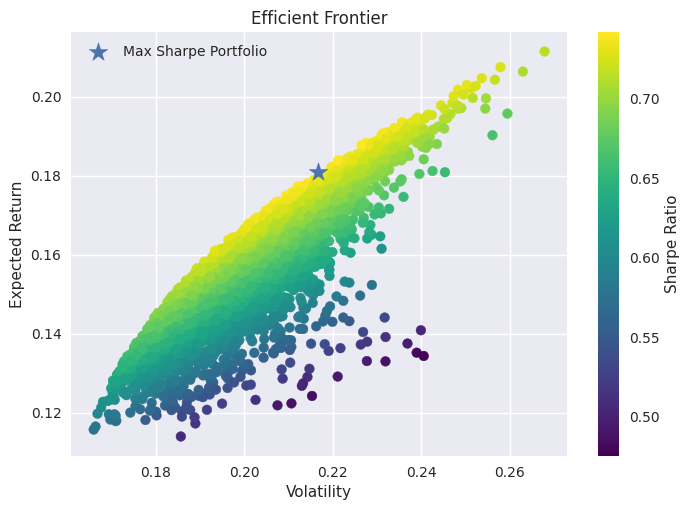

In [25]:
plt.figure()

scatter = plt.scatter(
    results[1, :],  # Volatilidad
    results[0, :],  # Retorno
    c=results[2, :],  # Sharpe
    cmap="viridis"
)

plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.scatter(
    opt_volatility,
    opt_return,
    marker="*",
    s=200,
    label="Max Sharpe Portfolio"
)

plt.legend()
plt.show()

In [26]:
def portfolio_volatility(weights, mean_returns, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

In [27]:
min_vol = minimize(
    portfolio_volatility,
    initial_weights,
    args=(mean_returns, cov_matrix),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

In [28]:
min_vol_weights = min_vol.x

min_return, min_volatility, min_sharpe = portfolio_performance(
    min_vol_weights,
    mean_returns,
    cov_matrix
)

min_return, min_volatility

(np.float64(0.11474788543864108), np.float64(0.1652314691748824))

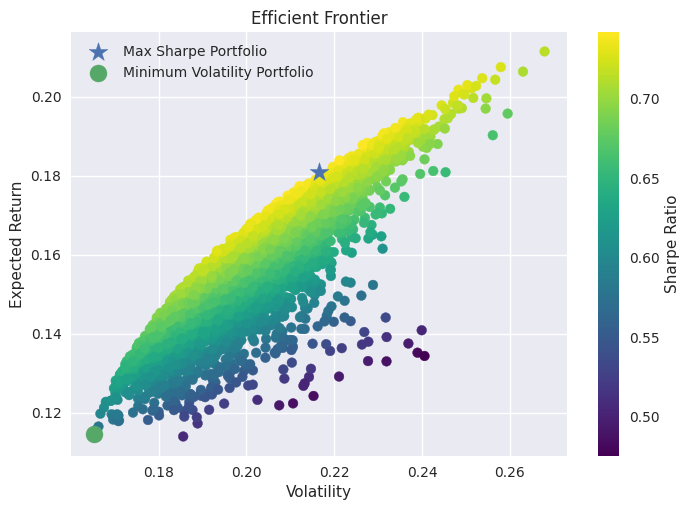

In [29]:
plt.figure()

scatter = plt.scatter(
    results[1, :],  # Volatilidad
    results[0, :],  # Retorno
    c=results[2, :],  # Sharpe
    cmap="viridis"
)

plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.scatter(
    opt_volatility,
    opt_return,
    marker="*",
    s=200,
    label="Max Sharpe Portfolio"
)
plt.scatter(
    min_volatility,
    min_return,
    marker="o",
    s=150,
    label="Minimum Volatility Portfolio"
)
plt.legend()
plt.show()

## SPY VS OPTIMAL PORTFOLIO

In [30]:
portfolio_daily_returns = returns.dot(optimal_weights)

In [31]:
portfolio_daily_returns.head()

Date
2018-01-03    0.005034
2018-01-04    0.004320
2018-01-05    0.009880
2018-01-08   -0.000580
2018-01-09    0.003342
dtype: float64

In [32]:
spy_returns = returns["SPY"]

In [33]:
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()
spy_cumulative = (1 + spy_returns).cumprod()

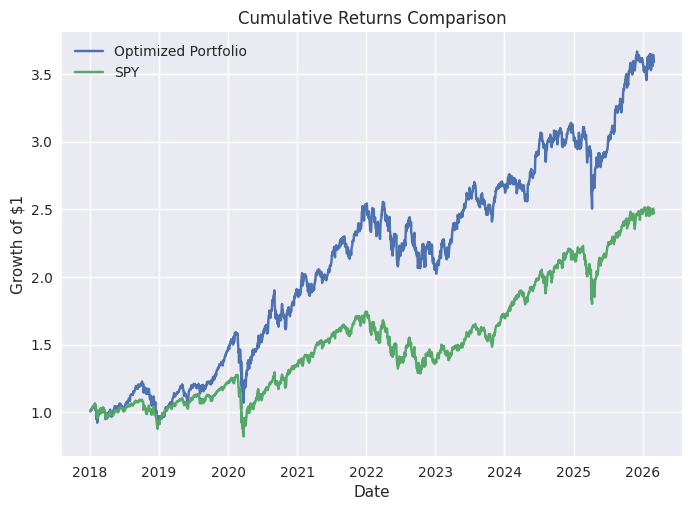

In [34]:
plt.figure()

plt.plot(portfolio_cumulative, label="Optimized Portfolio")
plt.plot(spy_cumulative, label="SPY")

plt.title("Cumulative Returns Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()

plt.show()

In [35]:
def calculate_metrics(daily_returns, risk_free_rate=0.02):
    
    annual_return = daily_returns.mean() * 252
    annual_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (annual_return - risk_free_rate) / annual_vol
    
    cumulative = (1 + daily_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()
    
    return annual_return, annual_vol, sharpe, max_drawdown

In [37]:
port_metrics = calculate_metrics(portfolio_daily_returns)
spy_metrics = calculate_metrics(spy_returns)

In [38]:
comparison = pd.DataFrame({
    "Metric": ["Annual Return", "Annual Volatility", "Sharpe Ratio", "Max Drawdown"],
    "Optimized Portfolio": port_metrics,
    "SPY": spy_metrics
})

comparison

,Metric,Optimized Portfolio,SPY
0,Annual Return,0.181002,0.130236
1,Annual Volatility,0.216562,0.193801
2,Sharpe Ratio,0.743445,0.568809
3,Max Drawdown,-0.326777,-0.357459
